In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')

In [2]:
def khoitao_u(dt, dx, tmax, L,f_x, g_x):
    n = int(tmax / dt) + 1   # n la thoi gian
    m = int(L / dx) + 1   # m la khong gian

    u = np.zeros((n, m))
    x = np.linspace(0, L, m)
    t = np.linspace(0, tmax, n)

    # Dieu kien dau theo thoi gian: u(0,x) = f(x), 
    for j in range(m):
        u[0, j] = f_x(x[j], L)
        u[1, j] = u[0, j] + dt * g_x(x[j], L)


    # Dieu kien theo khong gian tai moi thoi diem: u(0,t) = u(L,t) = 0
    u[:, 0] = 0.0
    u[:, -1] = 0.0

    return u, x, t

def tinh_beta(c,k,h):
    beta  = c * k / h
    if beta > 1:
        print("Canh bao: beta =", beta, " > 1. Phuong phap co the khong on dinh.")
        ondinh = False
    else:
        ondinh = True
        print("Gia tri beta =", beta, " <= 1. Phuong phap on dinh.")
        return beta, ondinh

In [3]:
def ghifile(u, x, t, beta, filename):
    filename = f"{filename}_beta_{beta:.2f}.txt"
    with open(filename, "w", encoding="utf-8") as file:
        file.write(f"# Bai toan truyen song 1D \n")
        file.write("# Phuong phap sai phan huu han hien\n")
        file.write("#\n")
        file.write(f"# N_x    = {x.shape[0]}\n")
        file.write(f"# N_time = {t.shape[0]}\n")
        file.write(f"# l      = {x[-1]}\n")
        file.write(f"# t_max  = {t[-1]}\n")
        file.write("#\n")
        file.write(f"# {'t_step':>10s} {'x_step':>10s} {'t':>15s} {'x':>15s} {'u':>15s}\n")

        for t_step in range(t.shape[0]):
            for x_step in range(x.shape[0]):
                file.write(f"  {t_step:10d} {x_step:10d} {t[t_step]:15.8e} {x[x_step]:15.8e} {u[t_step, x_step]:15.8e}\n")
            file.write("\n\n")

In [4]:
def ham_forward_khong_friction(c,k,h, tmax, L, f_x, g_x, filename):
    u, x ,t  = khoitao_u(k, h, tmax, L, f_x, g_x)
    n,m = u.shape
    beta, ondinh = tinh_beta(c, k, h)
    if ondinh == True:
        for i in range(1,n-1): # n la thoi gian
            for j in range(1,m-1): #  m la khong gian
                u[i+1,j] = 2*(1-beta**2)*u[i,j] + beta**2*(u[i,j+1]+u[i,j-1]) - u[i-1,j]
        ghifile(u, x, t, beta, filename)
    else:
        print("Phuong phap khong on dinh, khong the tinh toan.")
    return

## Bai 1 (khong friction)

In [5]:
## Ham bai 1
def f_x_bai1(x, l):
    if x <= 0.8*l:
        return 1.25*x/l
    else:
        return 5 - 5*x/l

## Van toc bai 1
def g_x_bai1(x, l):
    g_x  = 0
    return g_x

In [6]:
T = 40
rho = 0.01

c = np.sqrt(T/rho)  # Van toc song
print ("Van toc song c =", c)

L               = 1.0           # Chieu dai day
t_max           = 0.1           # Thoi gian mo phong
delta_x         = 0.007          # Buoc khong gian
delta_t         = 0.0001        # Buoc thoi gian  

beta_estimate = c * delta_t / delta_x
print("Beta du kien =", beta_estimate)

Van toc song c = 63.245553203367585
Beta du kien = 0.9035079029052513


In [7]:
ham_forward_khong_friction(c=c, k=delta_t, h=delta_x, tmax=t_max, L=L, f_x=f_x_bai1, g_x=g_x_bai1, filename="ketqua_bai1")

Gia tri beta = 0.9035079029052513  <= 1. Phuong phap on dinh.


In [12]:
t_063, x_063, u_063 = np.loadtxt("ketqua_bai1_beta_0.63.txt", comments='#', unpack=True, usecols=(2, 3, 4))
t_090, x_090, u_090 = np.loadtxt("ketqua_bai1_beta_0.90.txt", comments='#', unpack=True, usecols=(2, 3, 4))

In [20]:
def ve_3d(t_flat, x_flat, u_flat, beta, ax):
    x_vals = np.unique(x_flat)
    t_vals = np.unique(t_flat)
    nx = len(x_vals)
    nt = len(t_vals)

    T = t_flat.reshape(nt, nx)
    X = x_flat.reshape(nt, nx)
    U = u_flat.reshape(nt, nx)

    surf = ax.plot_surface(T, X, U, cmap='viridis', alpha=0.85)
    ax.set_xlabel('Thoi gian t (s)', labelpad=20)
    ax.set_ylabel('Vi tri x (m)', labelpad=20)
    ax.set_zlabel('Bien do u (m)', labelpad=20)
    return surf

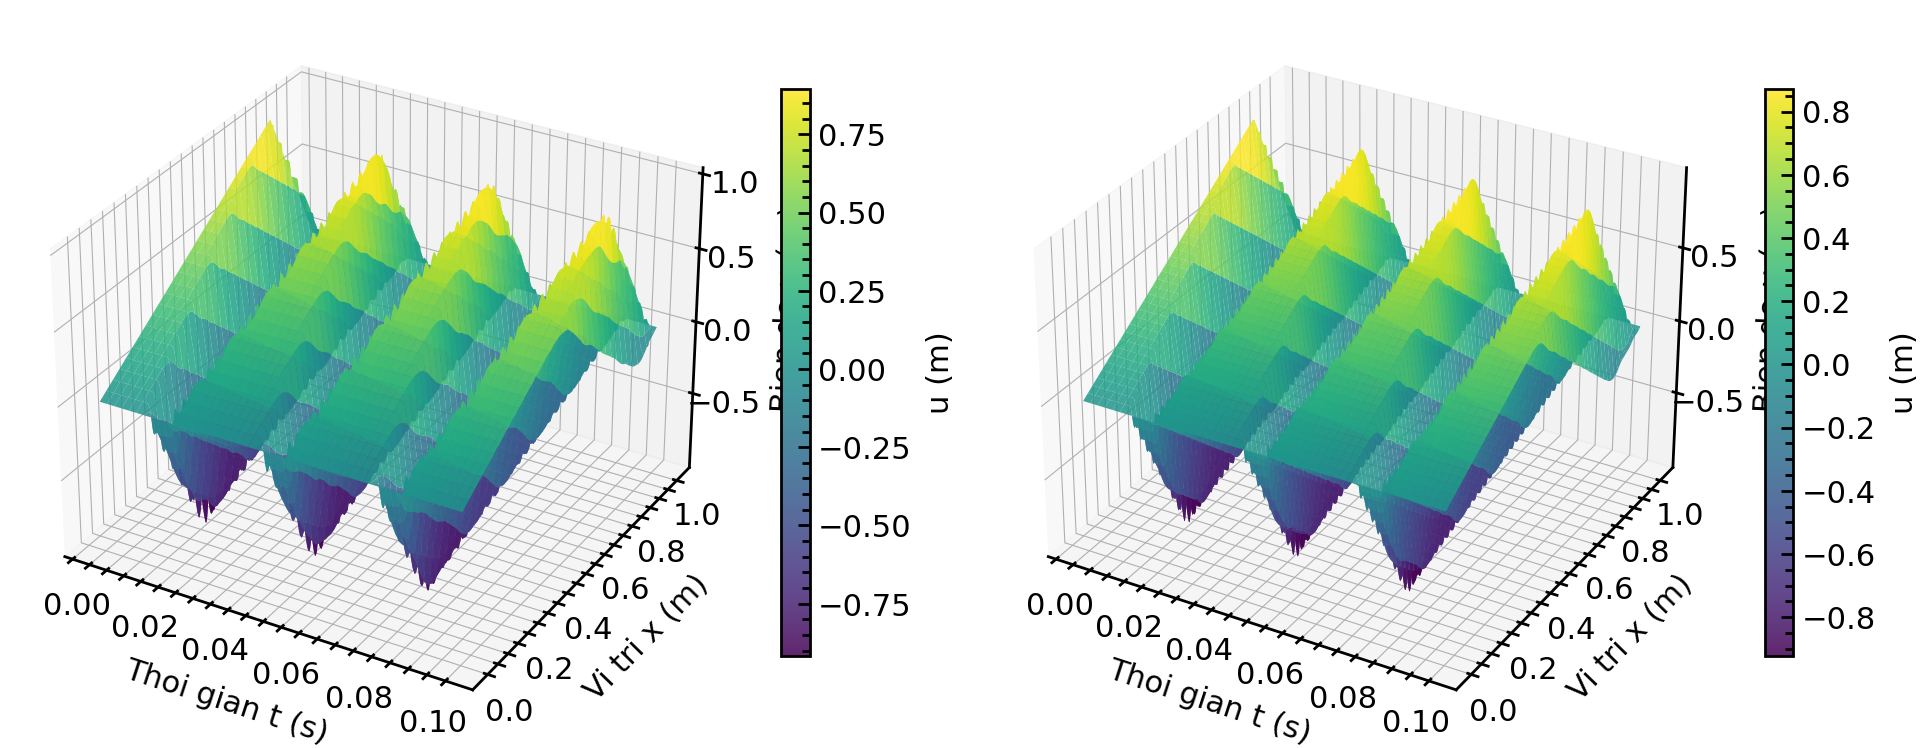

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(20, 12))

surf1 = ve_3d(t_063, x_063, u_063, beta=0.63, ax=ax1)
surf2 = ve_3d(t_090, x_090, u_090, beta=0.90, ax=ax2)

fig.colorbar(surf1, ax=ax1, shrink=0.5, label='u (m)')
fig.colorbar(surf2, ax=ax2, shrink=0.5, label='u (m)')

plt.tight_layout()
plt.savefig("wave_3d.pdf")
plt.show()

## Bai 1 (Ham sin)


In [8]:
def f_x_bai1_ham_sin(x, l):
    return np.sin(x * np.pi / l)
def g_x_bai1_ham_sin(x, l):
    return 0

In [27]:
ham_forward_khong_friction(c=c, k=delta_t, h=delta_x, tmax=t_max, L=L, f_x=f_x_bai1_ham_sin, g_x=g_x_bai1_ham_sin, filename="ketqua_bai1_hamsin")

Gia tri beta = 0.9035079029052513  <= 1. Phuong phap on dinh.


In [28]:
t_sin, x_sin, u_sin = np.loadtxt("ketqua_bai1_hamsin_beta_0.90.txt", comments='#', unpack=True, usecols=(2, 3, 4))

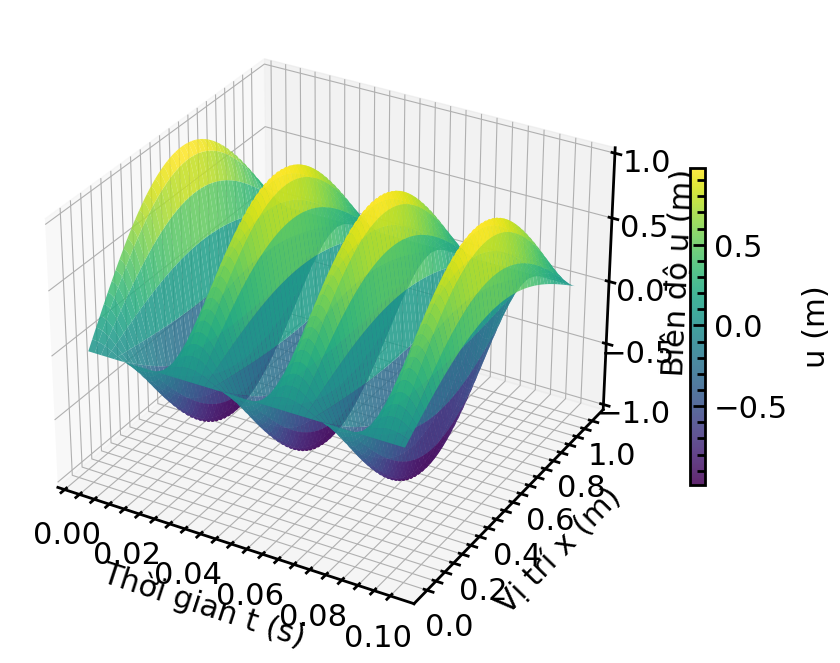

In [59]:
fig, ax1 = plt.subplots(1, 1, subplot_kw={'projection': '3d'}, figsize=(10, 7))

surf1 = ve_3d(t_sin, x_sin, u_sin, beta=0.90, ax=ax1)

fig.colorbar(surf1, ax=ax1, shrink=0.5, label='u (m)')

plt.tight_layout()
plt.savefig("wave_3d_sin.pdf")
plt.show()

## Bai 1 (co friction)

In [39]:
def ham_forward_friction(c, k, h, tmax, L, f_x, g_x, kappa, rho, filename):
    u, x, t = khoitao_u(k, h, tmax, L, f_x, g_x)
    n, m = u.shape

    beta, ondinh = tinh_beta(c, k, h)
    gamma = 2 * kappa * k / rho

    if ondinh:
        for i in range(1, n - 1):
            for j in range(1, m - 1):
                lap = u[i, j+1] - 2*u[i, j] + u[i, j-1]
                u[i+1, j] = (2-gamma)*u[i,j] + (gamma-1)*u[i-1,j] + beta**2*lap
        ghifile(u, x, t, beta, filename)
    else:
        print("Phuong phap khong on dinh, khong the tinh toan.")

    return u, x, t

In [56]:
kappa = [0.01, 1, 2, 5, 10]

for k in kappa:
    ham_forward_friction(c=c, k=delta_t, h=delta_x, tmax=t_max, L=L, f_x=f_x_bai1, g_x=g_x_bai1, kappa=k, rho=rho, filename=f"ketqua_bai1_co_friction_kappa_{k}")

Gia tri beta = 0.9035079029052513  <= 1. Phuong phap on dinh.
Gia tri beta = 0.9035079029052513  <= 1. Phuong phap on dinh.
Gia tri beta = 0.9035079029052513  <= 1. Phuong phap on dinh.
Gia tri beta = 0.9035079029052513  <= 1. Phuong phap on dinh.
Gia tri beta = 0.9035079029052513  <= 1. Phuong phap on dinh.
